# Hotel Price Trends Analysis
This notebook analyzes hotel prices over time across different locations in Switzerland.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)

## Load Data

In [2]:
df = pd.read_csv('../data/enriched_hotels_data.csv')
df['search_date'] = pd.to_datetime(df['search_date'], format='%d.%m.%Y')
print(f"Total records: {len(df)}")
print(f"Date range: {df['search_date'].min()} to {df['search_date'].max()}")
print(f"Locations: {df['location'].unique()}")
df.head()

Total records: 1923
Date range: 2026-01-05 00:00:00 to 2026-12-07 00:00:00
Locations: ['Arosa' 'Basel' 'Bern' 'Chur' 'Genf' 'Interlaken' 'Lausanne' 'Luzern'
 'St. Gallen' 'St. Moritz' 'Winterthur' 'Zermatt' 'Zuerich']


,search_date,day_of_week,location,hotel_id,hotel_name,price,currency,rating,address,city_code,...,is_school_vacation,temp_avg,temp_min,temp_max,precipitation_mm,snow_depth_cm,sunshine_hours,is_ski_season,hotel_chain,is_chain_hotel
0,2026-01-05,Monday,Arosa,BWZRH091,BEST WESTERN HOTEL ZURCHERHOF,570.64,CHF,4.5,"Poststrasse 95, Arosa",ZRH,...,False,-8.2,-11.3,-2.6,4.0,126,4.1,True,Best Western,True
1,2026-01-05,Monday,Arosa,MCZRHDTM,Zurich Marriott Hotel,732.90,CHF,4.5,"Marktplatz 10, Arosa",ZRH,...,False,-5.6,-11.0,-0.9,1.3,64,1.4,True,Marriott,True
2,2026-01-05,Monday,Arosa,ONZRHCTY,HOTEL CITY,438.36,CHF,4.3,"Hauptstrasse 54, Arosa",ZRH,...,False,-6.8,-12.6,-1.4,1.5,142,3.5,True,Independent,False
3,2026-01-05,Monday,Arosa,ONZRHMOT,HOTEL MONTANA,301.46,CHF,4.1,"Poststrasse 9, Arosa",ZRH,...,False,-9.5,-14.4,-5.1,0.0,94,1.3,True,Independent,False
4,2026-01-05,Monday,Arosa,XKZRH001,Hotel du Lac,239.68,CHF,3.9,"Bahnhofstrasse 13, Arosa",ZRH,...,False,-4.9,-9.0,1.9,1.6,131,2.9,True,Independent,False


## 1. Price Trends Over Time by Location
Visualizing how hotel prices change over time for each location.

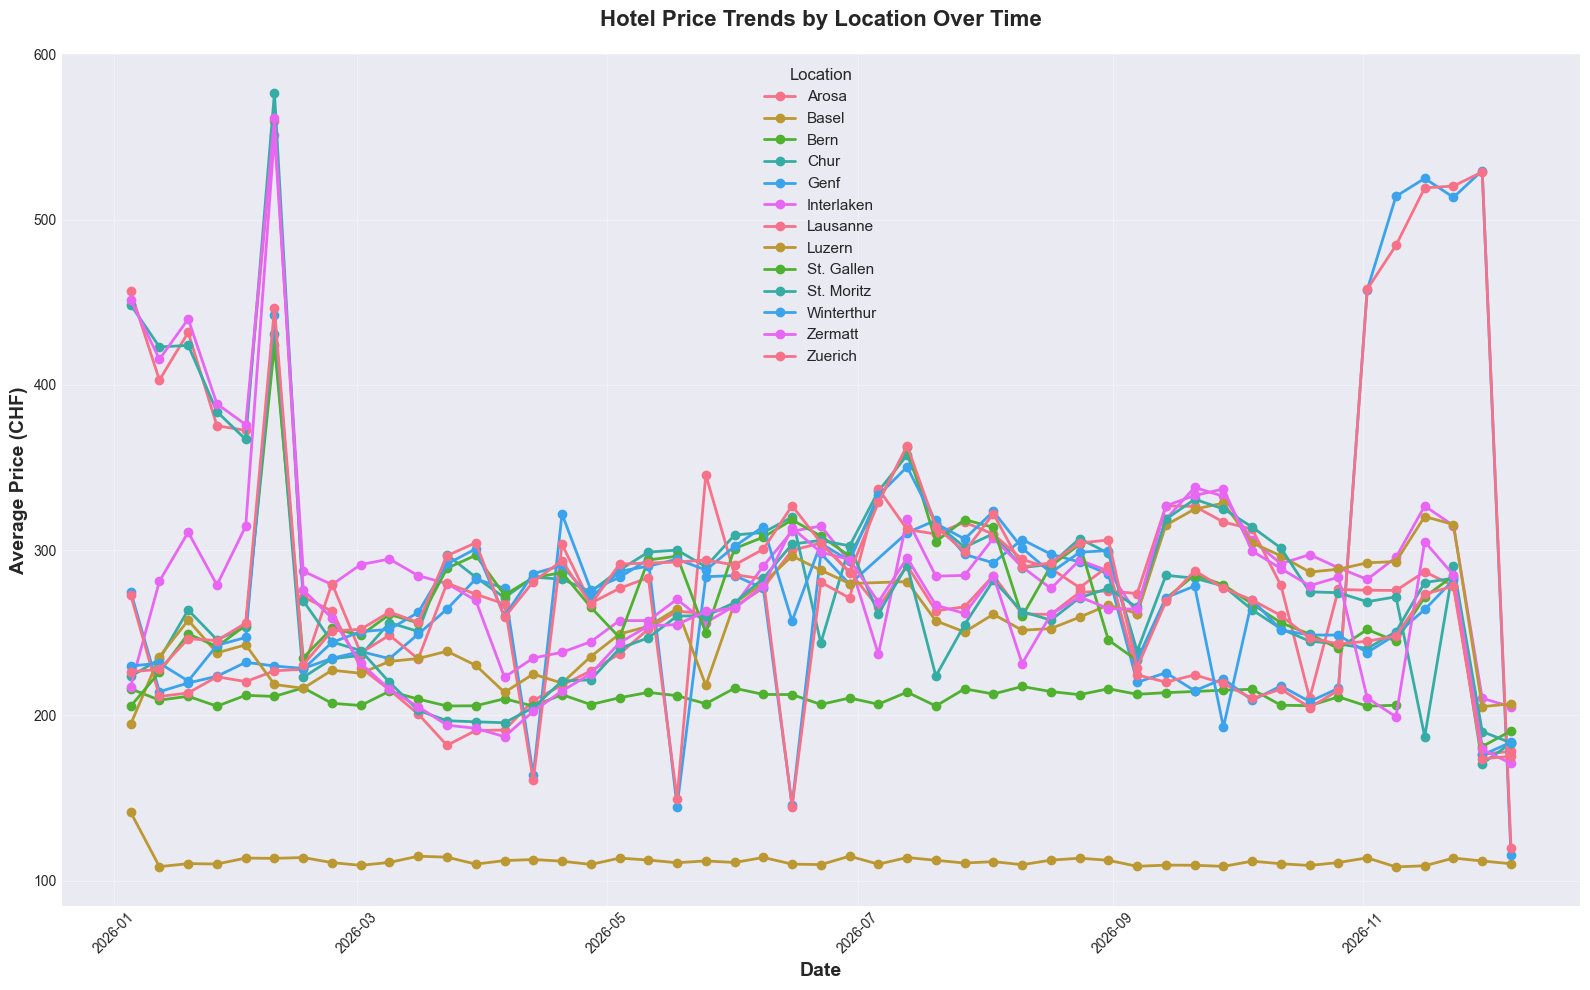

In [3]:
plt.figure(figsize=(16, 10))

for location in df['location'].unique():
    location_data = df[df['location'] == location]
    daily_avg = location_data.groupby('search_date')['price'].mean().reset_index()
    plt.plot(daily_avg['search_date'], daily_avg['price'], marker='o', label=location, linewidth=2, markersize=6)

plt.xlabel('Date', fontsize=14, fontweight='bold')
plt.ylabel('Average Price (CHF)', fontsize=14, fontweight='bold')
plt.title('Hotel Price Trends by Location Over Time', fontsize=16, fontweight='bold', pad=20)
plt.legend(title='Location', fontsize=11, title_fontsize=12, loc='best')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 2. Individual Hotel Price Scatter Plot
Showing all individual hotel prices (not aggregated) with color per location.

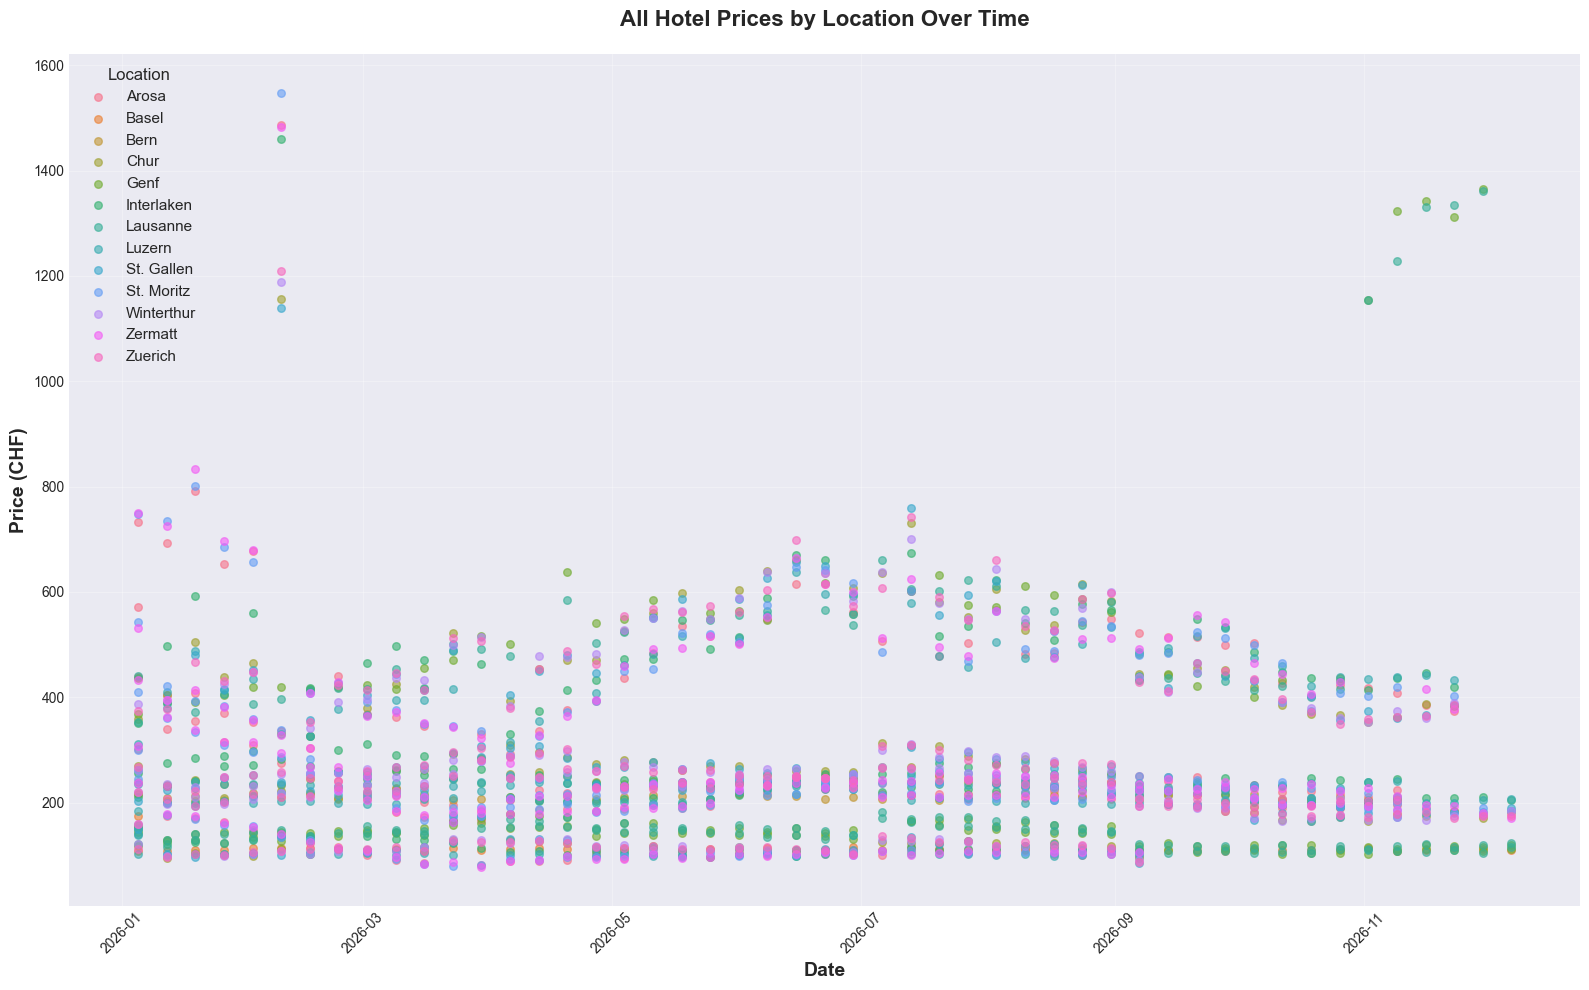

In [4]:
plt.figure(figsize=(16, 10))

locations = df['location'].unique()
colors = sns.color_palette("husl", len(locations))
location_color_map = dict(zip(locations, colors))

for location in locations:
    location_data = df[df['location'] == location]
    plt.scatter(location_data['search_date'], location_data['price'], 
               label=location, alpha=0.6, s=30, color=location_color_map[location])

plt.xlabel('Date', fontsize=14, fontweight='bold')
plt.ylabel('Price (CHF)', fontsize=14, fontweight='bold')
plt.title('All Hotel Prices by Location Over Time', fontsize=16, fontweight='bold', pad=20)
plt.legend(title='Location', fontsize=11, title_fontsize=12, loc='best')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3. Price Distribution by Location (Box Plot)

/var/folders/jh/_r4snhk531b72b_klw5898ph0000gn/T/ipykernel_68154/491438670.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='location', y='price', palette='Set2')


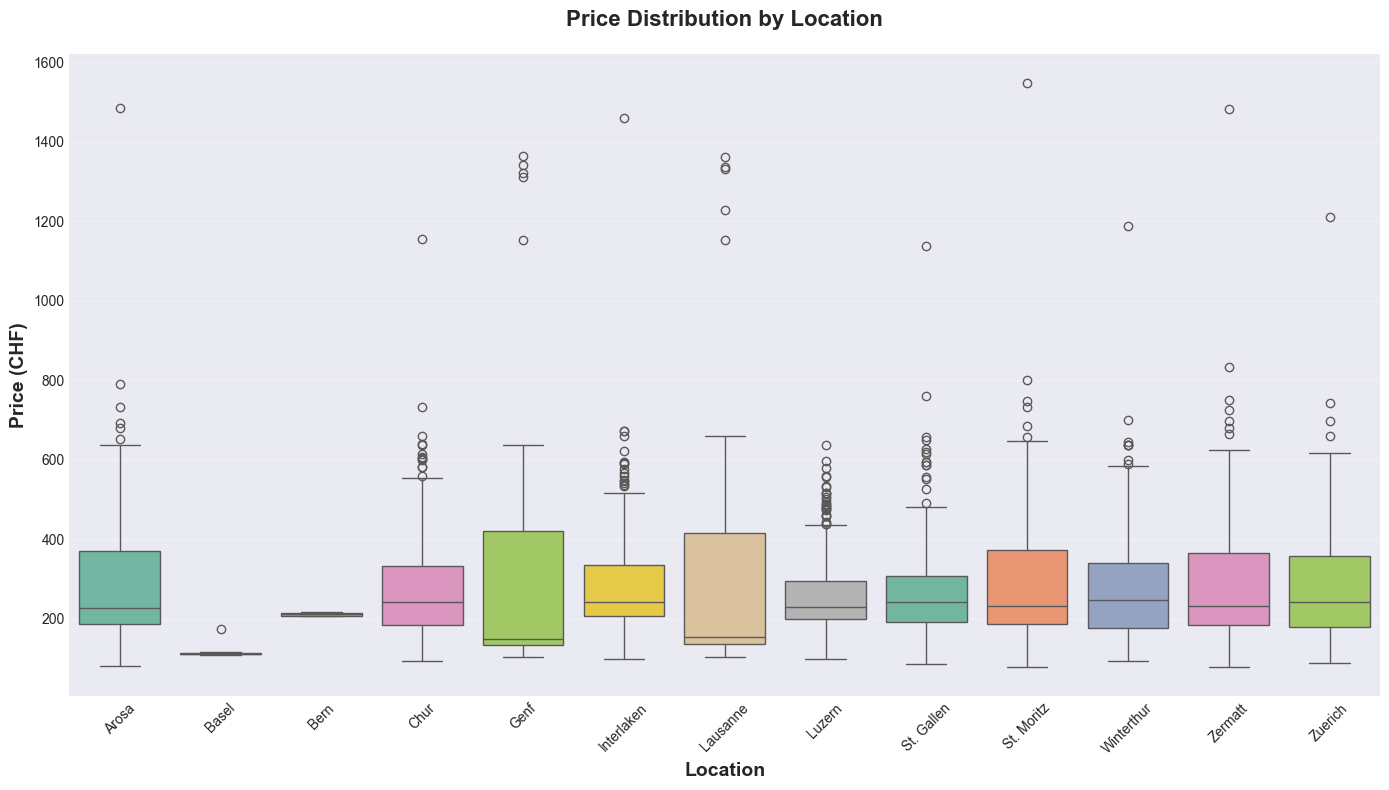

In [5]:
plt.figure(figsize=(14, 8))
sns.boxplot(data=df, x='location', y='price', palette='Set2')
plt.xlabel('Location', fontsize=14, fontweight='bold')
plt.ylabel('Price (CHF)', fontsize=14, fontweight='bold')
plt.title('Price Distribution by Location', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 4. Average Price Comparison Across Locations

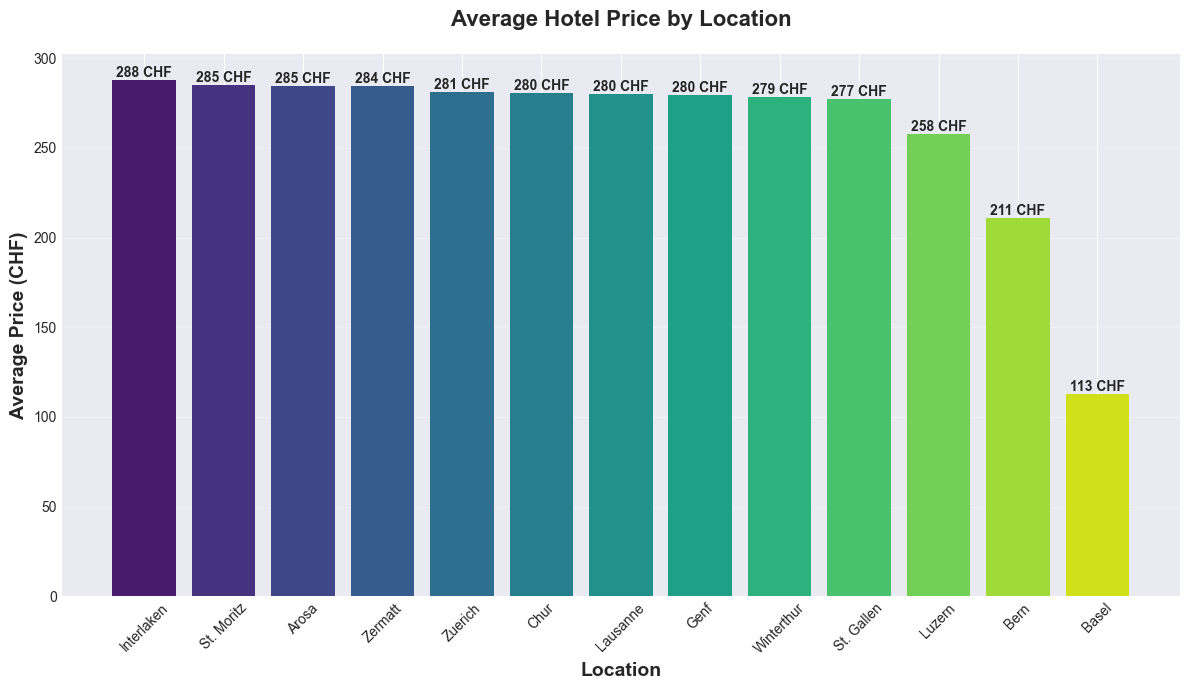


Average prices by location:
location
Interlaken    288.057209
St. Moritz    285.024104
Arosa         284.658971
Zermatt       284.326724
Zuerich       281.198596
Chur          280.399826
Lausanne      280.231690
Genf          279.796312
Winterthur    278.689133
St. Gallen    277.295494
Luzern        257.881867
Bern          210.992222
Basel         112.641200


In [6]:
avg_prices = df.groupby('location')['price'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 7))
bars = plt.bar(avg_prices.index, avg_prices.values, color=sns.color_palette("viridis", len(avg_prices)))
plt.xlabel('Location', fontsize=14, fontweight='bold')
plt.ylabel('Average Price (CHF)', fontsize=14, fontweight='bold')
plt.title('Average Hotel Price by Location', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.0f} CHF', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nAverage prices by location:")
print(avg_prices.to_string())

## 5. Price Trends by Week of Year

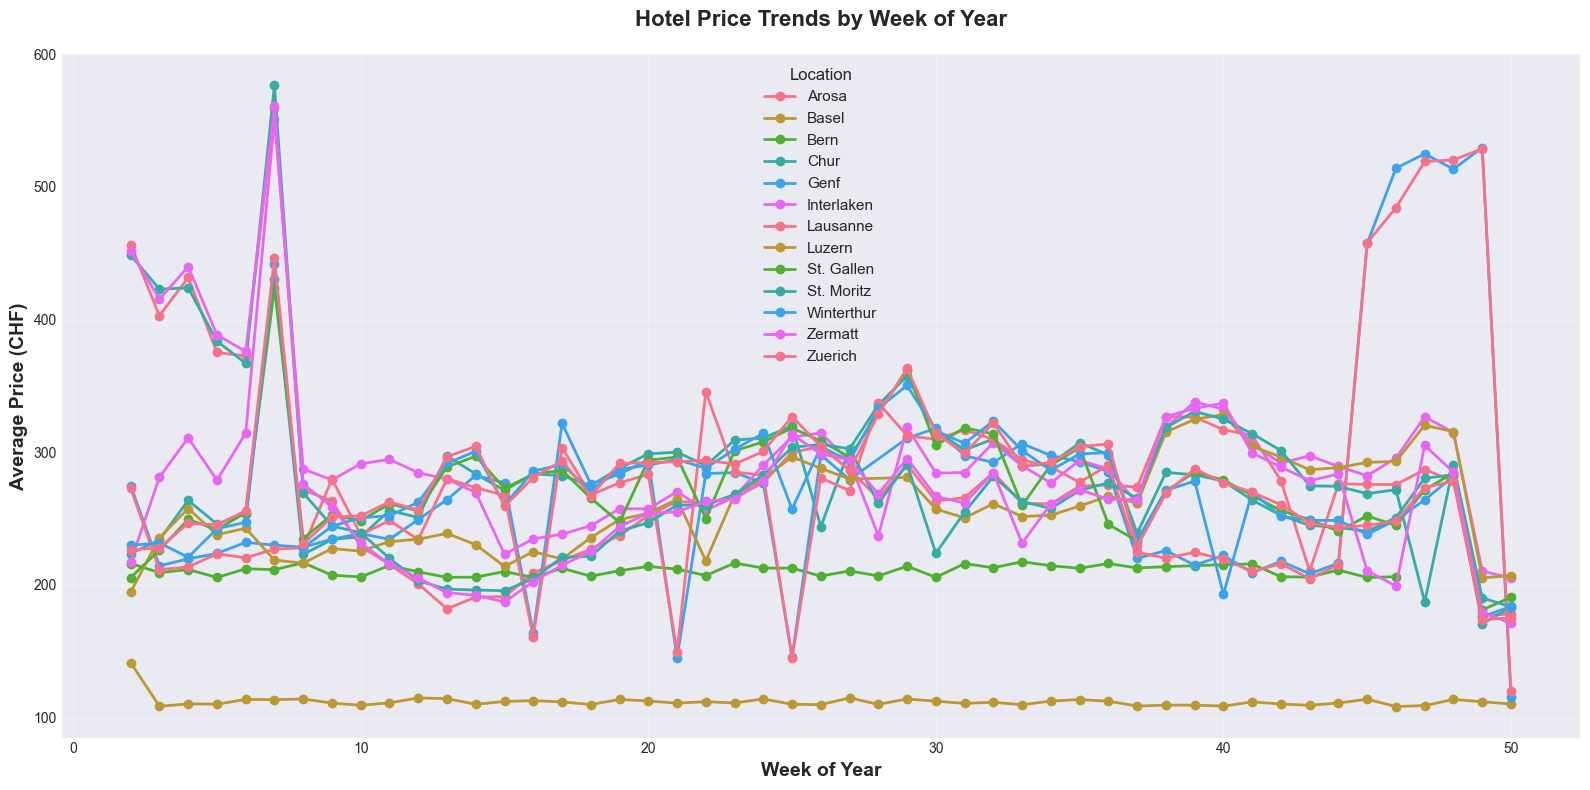

In [7]:
plt.figure(figsize=(16, 8))

for location in df['location'].unique():
    location_data = df[df['location'] == location]
    weekly_avg = location_data.groupby('week_of_year')['price'].mean().reset_index()
    plt.plot(weekly_avg['week_of_year'], weekly_avg['price'], marker='o', label=location, linewidth=2)

plt.xlabel('Week of Year', fontsize=14, fontweight='bold')
plt.ylabel('Average Price (CHF)', fontsize=14, fontweight='bold')
plt.title('Hotel Price Trends by Week of Year', fontsize=16, fontweight='bold', pad=20)
plt.legend(title='Location', fontsize=11, title_fontsize=12, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary Statistics

In [8]:
summary = df.groupby('location')['price'].agg(['mean', 'median', 'min', 'max', 'std']).round(2)
summary.columns = ['Average', 'Median', 'Min', 'Max', 'Std Dev']
print("\nPrice Statistics by Location:")
print(summary.to_string())


Price Statistics by Location:
            Average  Median     Min      Max  Std Dev
location                                             
Arosa        284.66  227.48   80.99  1486.49   178.83
Basel        112.64  111.07  108.37   174.25     9.09
Bern         210.99  211.61  205.62   217.54     3.89
Chur         280.40  242.12   94.04  1156.26   158.24
Genf         279.80  149.69  102.04  1364.54   257.75
Interlaken   288.06  241.76   97.63  1460.47   168.82
Lausanne     280.23  153.79  104.17  1361.51   253.26
Luzern       257.88  229.00   98.80   638.09   131.69
St. Gallen   277.30  242.10   85.68  1139.09   154.64
St. Moritz   285.02  231.62   78.99  1548.06   182.17
Winterthur   278.69  246.10   91.89  1187.57   157.40
Zermatt      284.33  230.38   77.87  1481.96   180.46
Zuerich      281.20  242.74   87.49  1210.28   161.30
